# 1. Objective

This notebook adds inferential statistics to the objective XAI metrics prepared by `07-metrics-analysis.ipynb`. It **loads the existing per-video CSV results** and does not recompute explanations, model predictions, or expensive metrics.

The same videos were evaluated with every XAI method, so method comparisons are repeated-measures comparisons. The Friedman test is the non-parametric omnibus test across all methods; when it is significant, paired Wilcoxon signed-rank tests locate pairwise differences and Holm correction controls family-wise error. These tests preserve the pairing by video and do not require normally distributed observations. Numerical rank alone is not evidence of statistically significant superiority.

## 2. Setup and Imports

In [13]:
from itertools import combinations
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy import stats

SEED = 42
ALPHA = 0.05
np.random.seed(SEED)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'artifacts').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULTS_DIR = PROJECT_ROOT / 'docs' / 'results'
FIGURES_DIR = PROJECT_ROOT / 'docs' / 'figures' / 'statistical-analysis'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

MODEL = 'TANet'
DATASETS = ['EtriActivity3D', 'Kinetics400']
SCOPES = ['Overall'] + DATASETS
METHODS = [
    '3D-Kernel-SHAP-NEW', '3D-LIME-NEW', '3D-RISE-NEW',
    '3D-Sampled-Occl-Sens-NEW', 'LV-LOCO-NEW', 'LV-Univ-Pred-NEW',
    'SaliencyTubes', 'AOSA', 'GradCAM',
]
DISPLAY_NAMES = {
    '3D-Kernel-SHAP-NEW': '3D-Kernel-SHAP',
    '3D-LIME-NEW': '3D-LIME',
    '3D-RISE-NEW': '3D-RISE',
    '3D-Sampled-Occl-Sens-NEW': '3D-Sampled-Occl-Sens',
    'LV-LOCO-NEW': 'LV-LOCO',
    'LV-Univ-Pred-NEW': 'LV-Univ-Pred',
    'SaliencyTubes': 'SaliencyTubes', 'AOSA': 'AOSA', 'GradCAM': 'GradCAM',
}

# Central direction configuration, reused from notebook 07.
METRIC_CONFIG = {
    'deletion_auc': {'higher_is_better': False, 'family': 'explanation_quality'},
    'insertion_auc': {'higher_is_better': True, 'family': 'explanation_quality'},
    'avg_drop': {'higher_is_better': False, 'family': 'explanation_quality'},
    'pointing_game': {'higher_is_better': True, 'family': 'explanation_quality'},
    'iou50': {'higher_is_better': True, 'family': 'explanation_quality'},
    'iou_value': {'higher_is_better': True, 'family': 'explanation_quality'},
    'bbox_energy_ratio': {'higher_is_better': True, 'family': 'explanation_quality'},
    'temporal_consistency': {'higher_is_better': True, 'family': 'explanation_quality'},
    'sparsity_80': {'higher_is_better': False, 'family': 'explanation_quality'},
    'runtime_seconds': {'higher_is_better': False, 'family': 'computational_cost'},
    'sensitivity_n': {'higher_is_better': True, 'family': 'sensitivity'},
    'roar': {'higher_is_better': True, 'family': 'retraining'},
}

plt.rcParams.update({'font.size': 10, 'axes.grid': True, 'grid.alpha': 0.25})

## 3. Load Existing Metric Results

Notebook 07 generated three core tidy per-video files and may also provide a Sensitivity-N cache. Original quality metrics use its dataset-local `video_idx`; their pairing therefore inherits notebook 07's assumption that every method's JSON arrays use the same within-dataset video order. Custom metrics, runtime, and Sensitivity-N use the stronger saved class/video-name key. Dataset is included in every block identifier, so the 60-video overall scope cannot collide across datasets. The runtime convention from notebook 07 is retained (its GradCAM timing source is the same timing file used for SaliencyTubes). ROAR is tracked in the shared taxonomy but is not treated as a repeated-video metric because its cache is aggregated at dataset × method × removal-fraction level.

In [14]:
INPUT_FILES = {
    'original': RESULTS_DIR / 'metrics_per_video.csv',
    'custom': RESULTS_DIR / 'custom_metrics_per_video.csv',
    'runtime': RESULTS_DIR / 'runtime_per_video.csv',
}
OPTIONAL_INPUT_FILES = {
    'sensitivity': RESULTS_DIR / 'sensitivity_n_per_video.csv',
    'roar': RESULTS_DIR / 'roar_results.csv',
}
TAXONOMY_PATH = RESULTS_DIR / 'metric_taxonomy.csv'
missing_files = [str(path) for path in INPUT_FILES.values() if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        'Run notebooks/07-metrics-analysis.ipynb first. Missing: ' + ', '.join(missing_files)
    )

source_frames = {name: pd.read_csv(path) for name, path in INPUT_FILES.items()}

# Sensitivity-N is an optional per-video cache. Apply notebook 07's canonical configuration.
SENSITIVITY_CONFIG = {'n': 10, 'n_subsets': 100, 'seed': 777}
sensitivity_path = OPTIONAL_INPUT_FILES['sensitivity']
if sensitivity_path.exists():
    sensitivity_frame = pd.read_csv(sensitivity_path)
    if not sensitivity_frame.empty:
        for column, expected in SENSITIVITY_CONFIG.items():
            sensitivity_frame = sensitivity_frame[sensitivity_frame[column].eq(expected)]
        sensitivity_frame = sensitivity_frame[sensitivity_frame['model'].eq(MODEL)].copy()
        sensitivity_frame['method_display'] = sensitivity_frame['method'].map(DISPLAY_NAMES)
        source_frames['sensitivity'] = sensitivity_frame

taxonomy_df = (pd.read_csv(TAXONOMY_PATH) if TAXONOMY_PATH.exists()
               else pd.DataFrame({'metric': list(METRIC_CONFIG),
                                      'category': [METRIC_CONFIG[m]['family'] for m in METRIC_CONFIG]}))
taxonomy_metrics = set(taxonomy_df['metric'])
{name: frame.shape for name, frame in source_frames.items()}

{'original': (540, 11),
 'custom': (540, 9),
 'runtime': (540, 7),
 'sensitivity': (540, 12)}

In [15]:
METADATA_COLUMNS = {
    'dataset', 'model', 'method', 'method_display',
    'video_idx', 'video_class', 'video_name',
}

def discover_metric_columns(frame):
    # Notebook 07's taxonomy is authoritative, so diagnostic/control columns are not misclassified.
    return [column for column in frame.columns if column in taxonomy_metrics]

def to_metric_long(frame, source_name):
    metric_columns = discover_metric_columns(frame)
    if 'video_idx' in frame.columns:
        sample_id = frame['dataset'].astype(str) + '::index::' + frame['video_idx'].astype(str)
    else:
        sample_id = (
            frame['dataset'].astype(str) + '::' + frame['video_class'].astype(str)
            + '::' + frame['video_name'].astype(str)
        )
    prepared = frame.assign(sample_id=sample_id, source=source_name)
    return prepared.melt(
        id_vars=['dataset', 'model', 'method', 'method_display', 'sample_id', 'source'],
        value_vars=metric_columns, var_name='metric', value_name='value',
    ), metric_columns

long_parts = []
discovered_by_source = {}
for source_name, frame in source_frames.items():
    part, columns = to_metric_long(frame, source_name)
    long_parts.append(part)
    discovered_by_source[source_name] = columns

metric_long = pd.concat(long_parts, ignore_index=True)
metric_long['value'] = pd.to_numeric(metric_long['value'], errors='coerce')
METRICS = list(dict.fromkeys(metric for columns in discovered_by_source.values() for metric in columns))
unconfigured = sorted(set(METRICS) - set(METRIC_CONFIG))
if unconfigured:
    raise ValueError(f'Add metric direction(s) to METRIC_CONFIG: {unconfigured}')
taxonomy_category = taxonomy_df.set_index('metric')['category'].to_dict()
metric_long['family'] = metric_long['metric'].map(taxonomy_category).fillna(
    metric_long['metric'].map(lambda metric: METRIC_CONFIG[metric]['family'])
)

availability_rows = []
for metric in taxonomy_df['metric']:
    observed = metric_long[metric_long['metric'].eq(metric)]
    if metric == 'roar':
        reason = 'Excluded: results are dataset/method/fraction-level, not per-video repeated measures.'
        included = False
    elif observed.empty:
        reason = 'Unavailable: no per-video cache rows.'
        included = False
    else:
        reason = 'Included; complete cases are determined per scope below.'
        included = True
    availability_rows.append({
        'Metric': metric, 'Category': taxonomy_category.get(metric),
        'Valid per-video values': int(observed['value'].notna().sum()),
        'Methods observed': int(observed['method'].nunique()),
        'Included in repeated-video analysis': included, 'Reason': reason,
    })
metric_availability_df = pd.DataFrame(availability_rows)
metric_availability_df.to_csv(RESULTS_DIR / 'statistical_metric_availability.csv', index=False)

display(pd.DataFrame([
    {
        'Metric': metric,
        'Source': next(source for source, columns in discovered_by_source.items() if metric in columns),
        'Direction': 'higher is better' if METRIC_CONFIG[metric]['higher_is_better'] else 'lower is better',
        'Family': taxonomy_category.get(metric, METRIC_CONFIG[metric]['family']),
    }
    for metric in METRICS
]))
display(metric_availability_df)

,Metric,Source,Direction,Family
0,deletion_auc,original,lower is better,input_perturbation
1,insertion_auc,original,higher is better,input_perturbation
2,avg_drop,original,lower is better,input_perturbation
3,pointing_game,original,higher is better,ground_truth_comparison
4,iou50,original,higher is better,ground_truth_comparison
5,iou_value,original,higher is better,ground_truth_comparison
6,bbox_energy_ratio,custom,higher is better,project_specific
7,temporal_consistency,custom,higher is better,project_specific
8,sparsity_80,custom,lower is better,project_specific
9,runtime_seconds,runtime,lower is better,computational_cost


,Metric,Category,Valid per-video values,Methods observed,Included in repeated-video analysis,Reason
0,deletion_auc,input_perturbation,540,9,True,Included; complete cases are determined per sc...
1,insertion_auc,input_perturbation,540,9,True,Included; complete cases are determined per sc...
2,avg_drop,input_perturbation,540,9,True,Included; complete cases are determined per sc...
3,pointing_game,ground_truth_comparison,540,9,True,Included; complete cases are determined per sc...
4,iou50,ground_truth_comparison,540,9,True,Included; complete cases are determined per sc...
5,iou_value,ground_truth_comparison,540,9,True,Included; complete cases are determined per sc...
6,sensitivity_n,sensitivity,540,9,True,Included; complete cases are determined per sc...
7,roar,retraining,0,0,False,Excluded: results are dataset/method/fraction-...
8,bbox_energy_ratio,project_specific,540,9,True,Included; complete cases are determined per sc...
9,temporal_consistency,project_specific,540,9,True,Included; complete cases are determined per sc...


## 4. Data Validation

Every statistical block must contain at most one value per dataset, metric, method, and sample. Coverage is checked against the nine configured methods. Complete-case filtering happens separately for each metric and scope; the global-test table reports both available blocks and rows removed.

In [16]:
if set(metric_long['model'].dropna().unique()) != {MODEL}:
    raise ValueError(f'Unexpected models: {sorted(metric_long["model"].dropna().unique())}')
if set(metric_long['dataset'].unique()) != set(DATASETS):
    raise ValueError(f'Unexpected datasets: {sorted(metric_long["dataset"].unique())}')
if set(metric_long['method'].unique()) != set(METHODS):
    raise ValueError('Observed XAI methods do not match the nine methods configured in notebook 07.')

key_columns = ['dataset', 'metric', 'method', 'sample_id']
duplicate_count = int(metric_long.duplicated(key_columns).sum())
if duplicate_count:
    raise ValueError(f'{duplicate_count} duplicate repeated-measure keys found.')

validation_df = (
    metric_long.groupby(['source', 'dataset', 'metric'])
    .agg(rows=('value', 'size'), valid_values=('value', 'count'),
         videos=('sample_id', 'nunique'), methods=('method', 'nunique'))
    .reset_index()
)
validation_df['missing_values'] = validation_df['rows'] - validation_df['valid_values']
validation_df['expected_rows'] = validation_df['videos'] * len(METHODS)
validation_df['complete_shape'] = (
    (validation_df['rows'] == validation_df['expected_rows'])
    & (validation_df['methods'] == len(METHODS))
)
display(validation_df)
print(f'Duplicate keys: {duplicate_count}; missing values: {int(metric_long.value.isna().sum())}')

,source,dataset,metric,rows,valid_values,videos,methods,missing_values,expected_rows,complete_shape
0,custom,EtriActivity3D,bbox_energy_ratio,270,270,30,9,0,270,True
1,custom,EtriActivity3D,sparsity_80,270,270,30,9,0,270,True
2,custom,EtriActivity3D,temporal_consistency,270,270,30,9,0,270,True
3,custom,Kinetics400,bbox_energy_ratio,270,270,30,9,0,270,True
4,custom,Kinetics400,sparsity_80,270,270,30,9,0,270,True
5,custom,Kinetics400,temporal_consistency,270,270,30,9,0,270,True
6,original,EtriActivity3D,avg_drop,270,270,30,9,0,270,True
7,original,EtriActivity3D,deletion_auc,270,270,30,9,0,270,True
8,original,EtriActivity3D,insertion_auc,270,270,30,9,0,270,True
9,original,EtriActivity3D,iou50,270,270,30,9,0,270,True


Duplicate keys: 0; missing values: 0


## 5. Descriptive Statistics

The table below contains N, mean, sample standard deviation, median, quartiles, and IQR for every dataset × method × discovered metric, plus the combined 60-video scope. It is saved in long form for direct thesis use.

In [17]:
def descriptive_statistics(data):
    scoped = pd.concat([
        data.assign(Dataset=data['dataset']),
        data.assign(Dataset='Overall'),
    ], ignore_index=True)
    summary = (
        scoped.groupby(['metric', 'Dataset', 'method', 'method_display'])['value']
        .agg(
            N='count', mean='mean', std='std', median='median',
            q25=lambda values: values.quantile(0.25),
            q75=lambda values: values.quantile(0.75),
        )
        .reset_index()
    )
    summary['IQR'] = summary['q75'] - summary['q25']
    summary['direction'] = summary['metric'].map(
        lambda metric: 'higher' if METRIC_CONFIG[metric]['higher_is_better'] else 'lower'
    )
    return summary.sort_values(['metric', 'Dataset', 'method_display']).reset_index(drop=True)

descriptive_df = descriptive_statistics(metric_long)
descriptive_df.to_csv(RESULTS_DIR / 'statistical_descriptive_summary.csv', index=False)
display(descriptive_df.round(4))

,metric,Dataset,method,method_display,N,mean,std,median,q25,q75,IQR,direction
0,avg_drop,EtriActivity3D,3D-Kernel-SHAP-NEW,3D-Kernel-SHAP,30,22.2154,24.6748,17.1348,0.0009,41.3132,41.3123,lower
1,avg_drop,EtriActivity3D,3D-LIME-NEW,3D-LIME,30,16.3615,26.3627,0.6543,0.0000,26.9995,26.9995,lower
2,avg_drop,EtriActivity3D,3D-RISE-NEW,3D-RISE,30,2.3191,7.1667,0.0001,0.0000,0.9070,0.9070,lower
3,avg_drop,EtriActivity3D,3D-Sampled-Occl-Sens-NEW,3D-Sampled-Occl-Sens,30,53.4685,44.1555,72.4849,4.3768,97.5397,93.1629,lower
4,avg_drop,EtriActivity3D,AOSA,AOSA,30,20.9533,31.9296,0.4261,0.0000,39.0462,39.0462,lower
...,...,...,...,...,...,...,...,...,...,...,...,...
292,temporal_consistency,Overall,AOSA,AOSA,60,0.9312,0.0599,0.9504,0.8871,0.9827,0.0956,higher
293,temporal_consistency,Overall,GradCAM,GradCAM,60,0.9375,0.0463,0.9466,0.9097,0.9694,0.0598,higher
294,temporal_consistency,Overall,LV-LOCO-NEW,LV-LOCO,60,0.9227,0.0479,0.9258,0.8842,0.9694,0.0852,higher
295,temporal_consistency,Overall,LV-Univ-Pred-NEW,LV-Univ-Pred,60,0.9477,0.0432,0.9539,0.9153,0.9884,0.0731,higher


## 6. Friedman Tests

For each scope and metric, columns are the nine methods and rows are video blocks. A row enters the test only when all nine values are finite. The null hypothesis is that the XAI methods have equivalent distributions/performance for that metric. Kendall's W is reported as `chi-square / (N × (k - 1))`, using the tie-corrected Friedman statistic returned by SciPy.

In [18]:
def complete_case_matrix(data, metric, scope):
    subset = data[data['metric'].eq(metric)]
    if scope != 'Overall':
        subset = subset[subset['dataset'].eq(scope)]
    matrix = subset.pivot(index='sample_id', columns='method', values='value').reindex(columns=METHODS)
    matrix = matrix.replace([np.inf, -np.inf], np.nan)
    return matrix, matrix.dropna(axis=0, how='any')

def friedman_test(data, metric, scope):
    available, complete = complete_case_matrix(data, metric, scope)
    n, k = complete.shape
    if n < 2 or k < 3:
        statistic, p_value = np.nan, np.nan
    elif np.all(np.ptp(complete.to_numpy(dtype=float), axis=1) == 0):
        statistic, p_value = 0.0, 1.0
    else:
        statistic, p_value = stats.friedmanchisquare(
            *[complete[method].to_numpy() for method in METHODS]
        )
    kendall_w = statistic / (n * (k - 1)) if n and np.isfinite(statistic) else np.nan
    return {
        'Metric': metric, 'Dataset': scope, 'N': n, 'Methods': k,
        'Available blocks': len(available), 'Rows removed': len(available) - n,
        'Friedman statistic': statistic, 'p': p_value, 'Kendall W': kendall_w,
        'Significant': bool(np.isfinite(p_value) and p_value < ALPHA),
    }

global_tests_df = pd.DataFrame([
    friedman_test(metric_long, metric, scope)
    for metric in METRICS for scope in SCOPES
])
global_tests_df.to_csv(RESULTS_DIR / 'friedman_global_tests.csv', index=False)
display(global_tests_df.round({'Friedman statistic': 4, 'p': 6, 'Kendall W': 4}))

,Metric,Dataset,N,Methods,Available blocks,Rows removed,Friedman statistic,p,Kendall W,Significant
0,deletion_auc,Overall,60,9,60,0,136.4356,0.000000,0.2842,True
1,deletion_auc,EtriActivity3D,30,9,30,0,83.4400,0.000000,0.3477,True
2,deletion_auc,Kinetics400,30,9,30,0,69.0756,0.000000,0.2878,True
3,insertion_auc,Overall,60,9,60,0,115.5067,0.000000,0.2406,True
4,insertion_auc,EtriActivity3D,30,9,30,0,108.5600,0.000000,0.4523,True
5,insertion_auc,Kinetics400,30,9,30,0,79.1022,0.000000,0.3296,True
6,avg_drop,Overall,60,9,60,0,187.9001,0.000000,0.3915,True
7,avg_drop,EtriActivity3D,30,9,30,0,94.2963,0.000000,0.3929,True
8,avg_drop,Kinetics400,30,9,30,0,133.8724,0.000000,0.5578,True
9,pointing_game,Overall,60,9,60,0,35.4225,0.000022,0.0738,True


## 7. Post-hoc Wilcoxon Tests

All 36 method pairs are tested only after a significant Friedman result. Each family is one metric × scope. Holm-adjusted p-values are computed with the step-down formula. All-zero paired differences are defined transparently as statistic 0, p = 1, and effect size 0 instead of allowing the test to fail.

In [19]:
def holm_adjust(p_values):
    p_values = np.asarray(p_values, dtype=float)
    order = np.argsort(p_values)
    sorted_p = p_values[order]
    adjusted_sorted = np.minimum(1.0, np.maximum.accumulate(
        (len(sorted_p) - np.arange(len(sorted_p))) * sorted_p
    ))
    adjusted = np.empty_like(adjusted_sorted)
    adjusted[order] = adjusted_sorted
    return adjusted

def paired_rank_biserial(differences):
    differences = np.asarray(differences, dtype=float)
    nonzero = differences[~np.isclose(differences, 0.0)]
    if len(nonzero) == 0:
        return 0.0
    ranks = stats.rankdata(np.abs(nonzero), method='average')
    return float((ranks[nonzero > 0].sum() - ranks[nonzero < 0].sum()) / ranks.sum())

def safe_wilcoxon(a, b):
    differences = np.asarray(a, dtype=float) - np.asarray(b, dtype=float)
    if np.all(np.isclose(differences, 0.0)):
        return 0.0, 1.0, 0.0
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', UserWarning)
        result = stats.wilcoxon(
            a, b, zero_method='wilcox', correction=False,
            alternative='two-sided', method='auto',
        )
    return float(result.statistic), float(result.pvalue), paired_rank_biserial(differences)

def posthoc_for_family(data, metric, scope):
    _, complete = complete_case_matrix(data, metric, scope)
    rows = []
    for method_a, method_b in combinations(METHODS, 2):
        a, b = complete[method_a].to_numpy(), complete[method_b].to_numpy()
        statistic, p_raw, effect = safe_wilcoxon(a, b)
        rows.append({
            'Metric': metric, 'Dataset': scope, 'N': len(complete),
            'Method A': DISPLAY_NAMES[method_a], 'Method B': DISPLAY_NAMES[method_b],
            'Wilcoxon statistic': statistic, 'p raw': p_raw,
            'Mean difference (A-B)': float(np.mean(a - b)),
            'Median difference (A-B)': float(np.median(a - b)),
            'Rank-biserial effect': effect,
        })
    family = pd.DataFrame(rows)
    family['p Holm'] = holm_adjust(family['p raw'])
    family['Significant'] = family['p Holm'] < ALPHA
    return family

posthoc_families = []
for row in global_tests_df.itertuples(index=False):
    if row.Significant:
        posthoc_families.append(posthoc_for_family(metric_long, row.Metric, row.Dataset))

POSTHOC_COLUMNS = [
    'Metric', 'Dataset', 'N', 'Method A', 'Method B', 'Wilcoxon statistic',
    'p raw', 'p Holm', 'Mean difference (A-B)', 'Median difference (A-B)',
    'Rank-biserial effect', 'Significant',
]
posthoc_df = (pd.concat(posthoc_families, ignore_index=True)[POSTHOC_COLUMNS]
              if posthoc_families else pd.DataFrame(columns=POSTHOC_COLUMNS))
posthoc_df.to_csv(RESULTS_DIR / 'wilcoxon_holm_posthoc.csv', index=False)
display(posthoc_df.round(5))
display(posthoc_df.groupby(['Metric', 'Dataset']).size().rename('Comparisons').reset_index())

,Metric,Dataset,N,Method A,Method B,Wilcoxon statistic,p raw,p Holm,Mean difference (A-B),Median difference (A-B),Rank-biserial effect,Significant
0,deletion_auc,Overall,60,3D-Kernel-SHAP,3D-LIME,317.0,0.00001,0.00025,0.03687,0.02346,0.65355,True
1,deletion_auc,Overall,60,3D-Kernel-SHAP,3D-RISE,842.0,0.59099,1.00000,0.00520,0.00140,0.07978,False
2,deletion_auc,Overall,60,3D-Kernel-SHAP,3D-Sampled-Occl-Sens,259.0,0.00000,0.00004,-0.13272,-0.08973,-0.71694,True
3,deletion_auc,Overall,60,3D-Kernel-SHAP,LV-LOCO,303.0,0.00001,0.00017,-0.08273,-0.05620,-0.66885,True
4,deletion_auc,Overall,60,3D-Kernel-SHAP,LV-Univ-Pred,137.0,0.00000,0.00000,-0.23050,-0.24246,-0.85027,True
...,...,...,...,...,...,...,...,...,...,...,...,...
1147,sensitivity_n,Kinetics400,30,LV-Univ-Pred,AOSA,74.0,0.00067,0.01600,-0.18762,-0.20164,-0.68172,True
1148,sensitivity_n,Kinetics400,30,LV-Univ-Pred,GradCAM,27.0,0.00000,0.00008,-0.28060,-0.30159,-0.88387,True
1149,sensitivity_n,Kinetics400,30,SaliencyTubes,AOSA,181.0,0.29884,1.00000,0.03426,0.06147,0.22151,False
1150,sensitivity_n,Kinetics400,30,SaliencyTubes,GradCAM,71.0,0.00051,0.01314,-0.05872,-0.04794,-0.69462,True


,Metric,Dataset,Comparisons
0,avg_drop,EtriActivity3D,36
1,avg_drop,Kinetics400,36
2,avg_drop,Overall,36
3,bbox_energy_ratio,EtriActivity3D,36
4,bbox_energy_ratio,Kinetics400,36
5,bbox_energy_ratio,Overall,36
6,deletion_auc,EtriActivity3D,36
7,deletion_auc,Kinetics400,36
8,deletion_auc,Overall,36
9,insertion_auc,EtriActivity3D,36


## 8. Effect Sizes

Kendall's W accompanies each Friedman test. For paired Wilcoxon comparisons, rank-biserial correlation is `(W+ - W-) / (W+ + W-)` after zero differences are removed; its sign describes A minus B on the metric's raw scale. Magnitude, practical importance, and the configured metric direction should be interpreted together.

In [20]:
effect_size_summary = global_tests_df[[
    'Metric', 'Dataset', 'N', 'Kendall W', 'Significant'
]].copy()
display(effect_size_summary.round(4))
if not posthoc_df.empty:
    display(posthoc_df.loc[posthoc_df['Significant'], [
        'Metric', 'Dataset', 'Method A', 'Method B', 'p Holm', 'Rank-biserial effect'
    ]].round(4))

,Metric,Dataset,N,Kendall W,Significant
0,deletion_auc,Overall,60,0.2842,True
1,deletion_auc,EtriActivity3D,30,0.3477,True
2,deletion_auc,Kinetics400,30,0.2878,True
3,insertion_auc,Overall,60,0.2406,True
4,insertion_auc,EtriActivity3D,30,0.4523,True
5,insertion_auc,Kinetics400,30,0.3296,True
6,avg_drop,Overall,60,0.3915,True
7,avg_drop,EtriActivity3D,30,0.3929,True
8,avg_drop,Kinetics400,30,0.5578,True
9,pointing_game,Overall,60,0.0738,True


,Metric,Dataset,Method A,Method B,p Holm,Rank-biserial effect
0,deletion_auc,Overall,3D-Kernel-SHAP,3D-LIME,0.0002,0.6536
2,deletion_auc,Overall,3D-Kernel-SHAP,3D-Sampled-Occl-Sens,0.0000,-0.7169
3,deletion_auc,Overall,3D-Kernel-SHAP,LV-LOCO,0.0002,-0.6689
4,deletion_auc,Overall,3D-Kernel-SHAP,LV-Univ-Pred,0.0000,-0.8503
6,deletion_auc,Overall,3D-Kernel-SHAP,AOSA,0.0087,-0.5180
...,...,...,...,...,...,...
1144,sensitivity_n,Kinetics400,LV-LOCO,AOSA,0.0283,0.6516
1146,sensitivity_n,Kinetics400,LV-Univ-Pred,SaliencyTubes,0.0053,-0.7376
1147,sensitivity_n,Kinetics400,LV-Univ-Pred,AOSA,0.0160,-0.6817
1148,sensitivity_n,Kinetics400,LV-Univ-Pred,GradCAM,0.0001,-0.8839


## 9. XAI Method Rankings

Methods are ranked by mean performance within each metric and scope, respecting the direction configuration. Mean and median are both retained. Ties receive average ranks. `best` and `worst` identify numerical endpoints only; statistically supported pairwise differences are exclusively those marked significant in the Holm table.

In [21]:
def build_rankings(descriptive):
    ranked_groups = []
    for (metric, scope), group in descriptive.groupby(['metric', 'Dataset'], sort=False):
        group = group.copy()
        ascending = not METRIC_CONFIG[metric]['higher_is_better']
        group['Rank'] = group['mean'].rank(method='average', ascending=ascending)
        group['Best'] = group['Rank'].eq(group['Rank'].min())
        group['Worst'] = group['Rank'].eq(group['Rank'].max())
        ranked_groups.append(group)
    ranking = pd.concat(ranked_groups, ignore_index=True)
    ranking = ranking.rename(columns={
        'metric': 'Metric', 'method_display': 'Method', 'mean': 'Mean', 'median': 'Median'
    })
    return ranking.sort_values(['Metric', 'Dataset', 'Rank', 'Method']).reset_index(drop=True)

ranking_df = build_rankings(descriptive_df)
ranking_columns = ['Metric', 'Dataset', 'Rank', 'Method', 'Mean', 'Median', 'N', 'Best', 'Worst']
ranking_df[ranking_columns].to_csv(RESULTS_DIR / 'xai_method_rankings.csv', index=False)
display(ranking_df[ranking_columns].round(4))

,Metric,Dataset,Rank,Method,Mean,Median,N,Best,Worst
0,avg_drop,EtriActivity3D,1.0,3D-RISE,2.3191,0.0001,30,True,False
1,avg_drop,EtriActivity3D,2.0,3D-LIME,16.3615,0.6543,30,False,False
2,avg_drop,EtriActivity3D,3.0,SaliencyTubes,20.1009,4.8027,30,False,False
3,avg_drop,EtriActivity3D,4.0,AOSA,20.9533,0.4261,30,False,False
4,avg_drop,EtriActivity3D,5.0,3D-Kernel-SHAP,22.2154,17.1348,30,False,False
...,...,...,...,...,...,...,...,...,...
292,temporal_consistency,Overall,5.0,3D-Kernel-SHAP,0.9350,0.9512,60,False,False
293,temporal_consistency,Overall,6.0,AOSA,0.9312,0.9504,60,False,False
294,temporal_consistency,Overall,7.0,LV-LOCO,0.9227,0.9258,60,False,False
295,temporal_consistency,Overall,8.0,3D-RISE,0.4457,0.4449,60,False,False


## 10. Analysis by Dataset

The dataset-specific Friedman rows above compare methods within ETRI and within Kinetics using paired videos. This secondary analysis asks a different question: whether a given method's values differ between datasets. ETRI and Kinetics contain unrelated videos, so a paired test would be invalid. Two-sided Mann–Whitney U tests therefore treat datasets as independent samples; Holm correction is applied across the nine methods separately for each metric. The independent rank-biserial effect is `2U/(n_ETRI × n_Kinetics) - 1`, positive when ETRI tends to have larger raw values.

In [22]:
def dataset_comparisons(data):
    all_families = []
    for metric in METRICS:
        rows = []
        for method in METHODS:
            subset = data[data['metric'].eq(metric) & data['method'].eq(method)]
            etri = subset.loc[subset['dataset'].eq(DATASETS[0]), 'value'].dropna().to_numpy()
            kinetics = subset.loc[subset['dataset'].eq(DATASETS[1]), 'value'].dropna().to_numpy()
            if len(etri) and len(kinetics):
                result = stats.mannwhitneyu(etri, kinetics, alternative='two-sided', method='auto')
                u_stat, p_raw = float(result.statistic), float(result.pvalue)
                effect = 2 * u_stat / (len(etri) * len(kinetics)) - 1
            else:
                u_stat, p_raw, effect = np.nan, np.nan, np.nan
            rows.append({
                'Metric': metric, 'Method': DISPLAY_NAMES[method],
                'N ETRI': len(etri), 'N Kinetics': len(kinetics),
                'Mann-Whitney U': u_stat, 'p raw': p_raw,
                'Rank-biserial effect (ETRI-Kinetics)': effect,
                'Median ETRI': np.median(etri) if len(etri) else np.nan,
                'Median Kinetics': np.median(kinetics) if len(kinetics) else np.nan,
            })
        family = pd.DataFrame(rows)
        valid = family['p raw'].notna()
        family['p Holm'] = np.nan
        family.loc[valid, 'p Holm'] = holm_adjust(family.loc[valid, 'p raw'])
        family['Significant'] = family['p Holm'] < ALPHA
        all_families.append(family)
    return pd.concat(all_families, ignore_index=True)

dataset_comparison_df = dataset_comparisons(metric_long)
dataset_comparison_df.to_csv(RESULTS_DIR / 'dataset_mannwhitney_holm.csv', index=False)
display(dataset_comparison_df.round(5))

,Metric,Method,N ETRI,N Kinetics,Mann-Whitney U,p raw,Rank-biserial effect (ETRI-Kinetics),Median ETRI,Median Kinetics,p Holm,Significant
0,deletion_auc,3D-Kernel-SHAP,30,30,313.0,0.04358,-0.30444,0.08995,0.15940,0.30508,False
1,deletion_auc,3D-LIME,30,30,337.0,0.09626,-0.25111,0.07603,0.12289,0.57758,False
2,deletion_auc,3D-RISE,30,30,276.0,0.01031,-0.38667,0.09893,0.17600,0.08252,False
3,deletion_auc,3D-Sampled-Occl-Sens,30,30,471.0,0.76183,0.04667,0.31645,0.24076,1.00000,False
4,deletion_auc,LV-LOCO,30,30,365.0,0.21156,-0.18889,0.15779,0.22414,1.00000,False
...,...,...,...,...,...,...,...,...,...,...,...
94,sensitivity_n,LV-LOCO,30,30,583.0,0.05012,0.29556,0.51696,0.41022,0.40096,False
95,sensitivity_n,LV-Univ-Pred,30,30,591.0,0.03778,0.31333,0.09874,-0.00696,0.34004,False
96,sensitivity_n,SaliencyTubes,30,30,415.0,0.61001,-0.07778,0.17503,0.28477,1.00000,False
97,sensitivity_n,AOSA,30,30,379.0,0.29727,-0.15778,0.14557,0.20990,1.00000,False


## 11. Visualizations

Each discovered metric gets one compact three-panel boxplot (overall, ETRI, Kinetics). Within a panel, methods are ordered by median in the configured performance direction. Boxplots show distributions, pairing is handled in the tests rather than drawn as 60 × 9 connecting lines, and no visual ordering should be read as proof of significance.

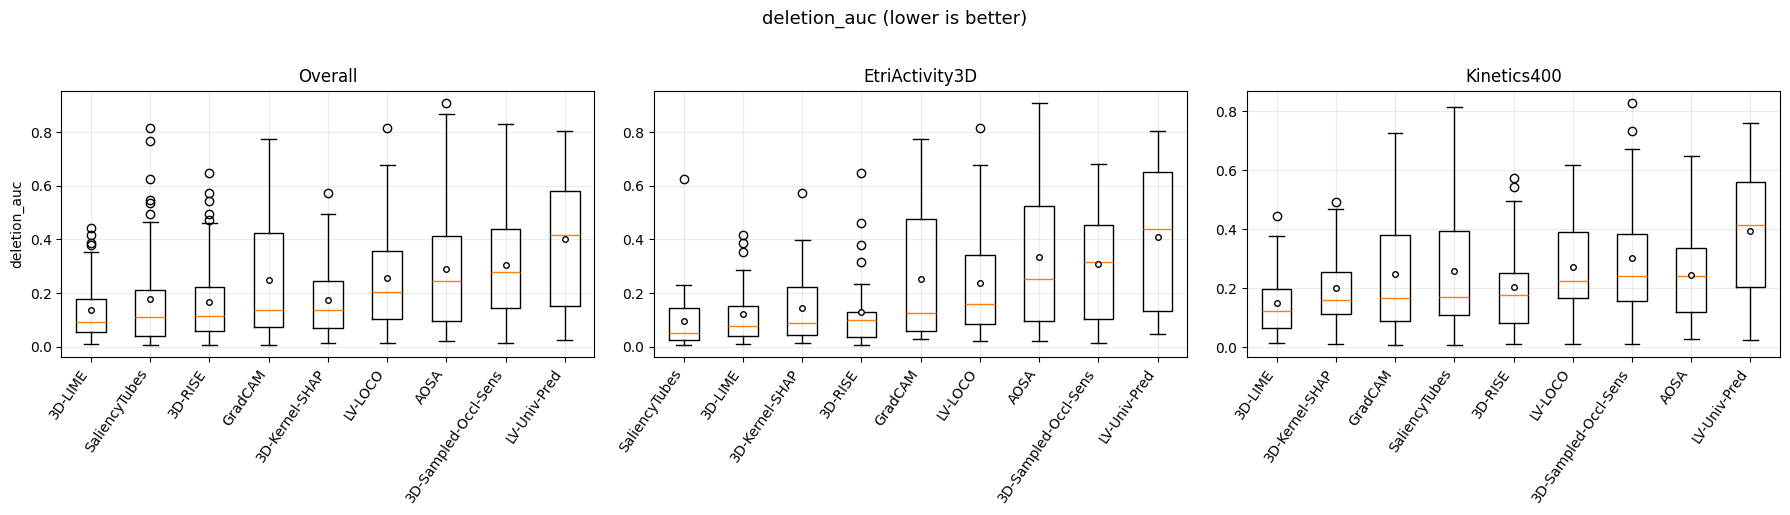

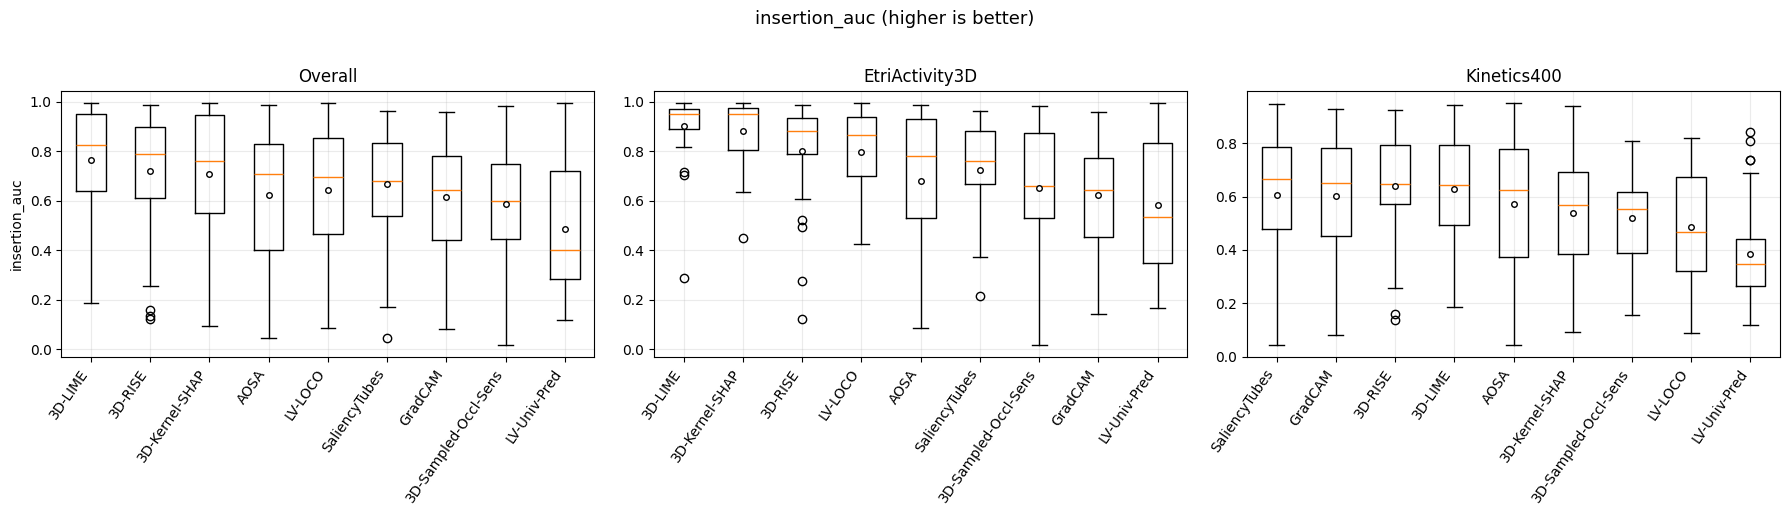

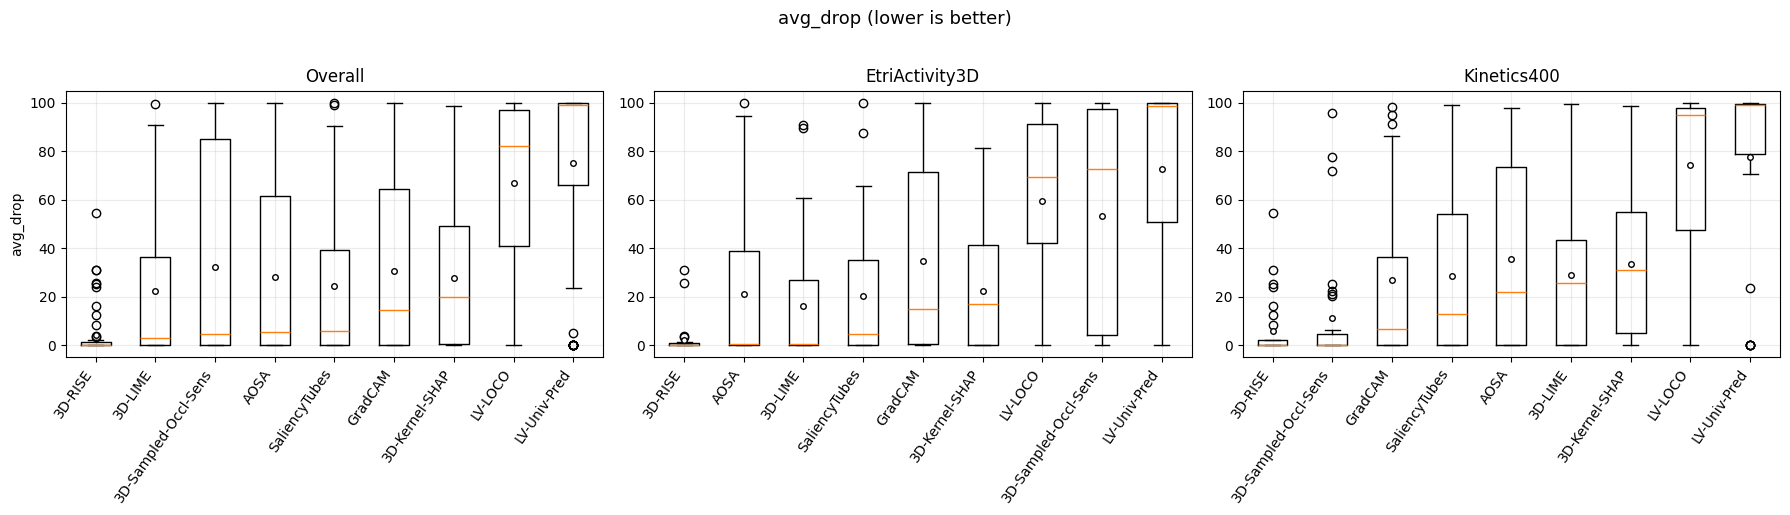

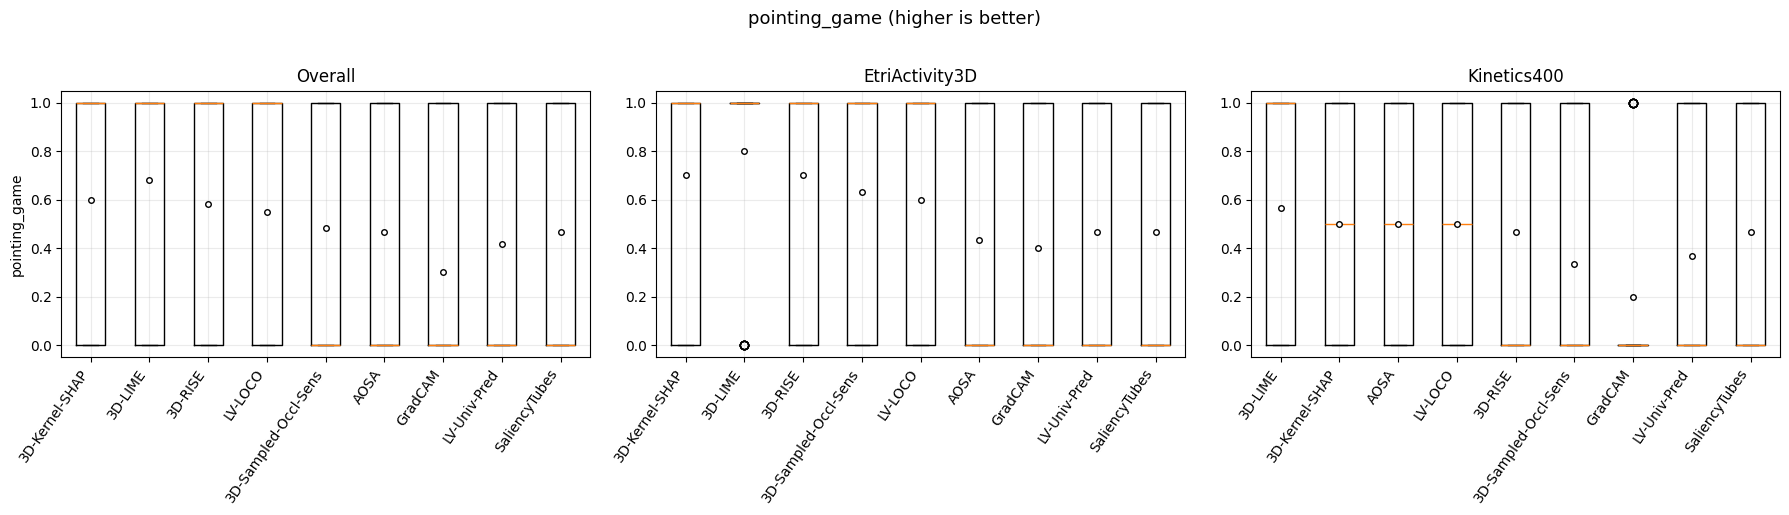

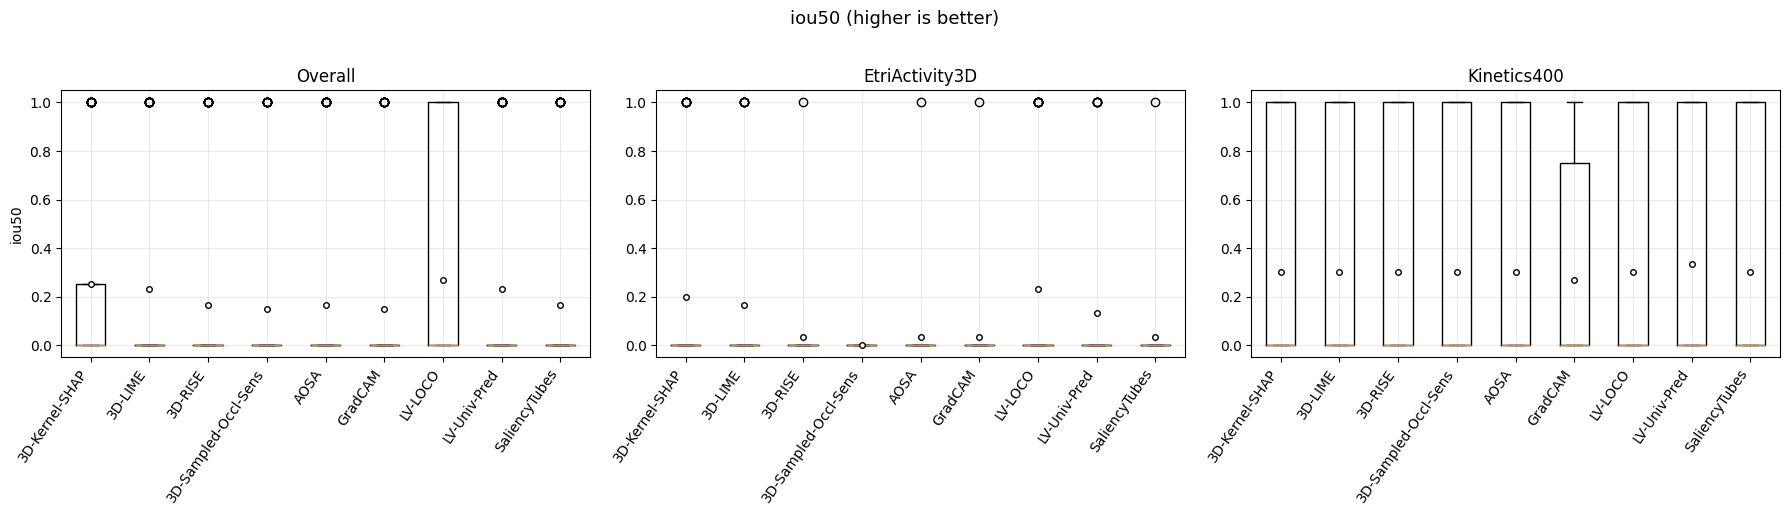

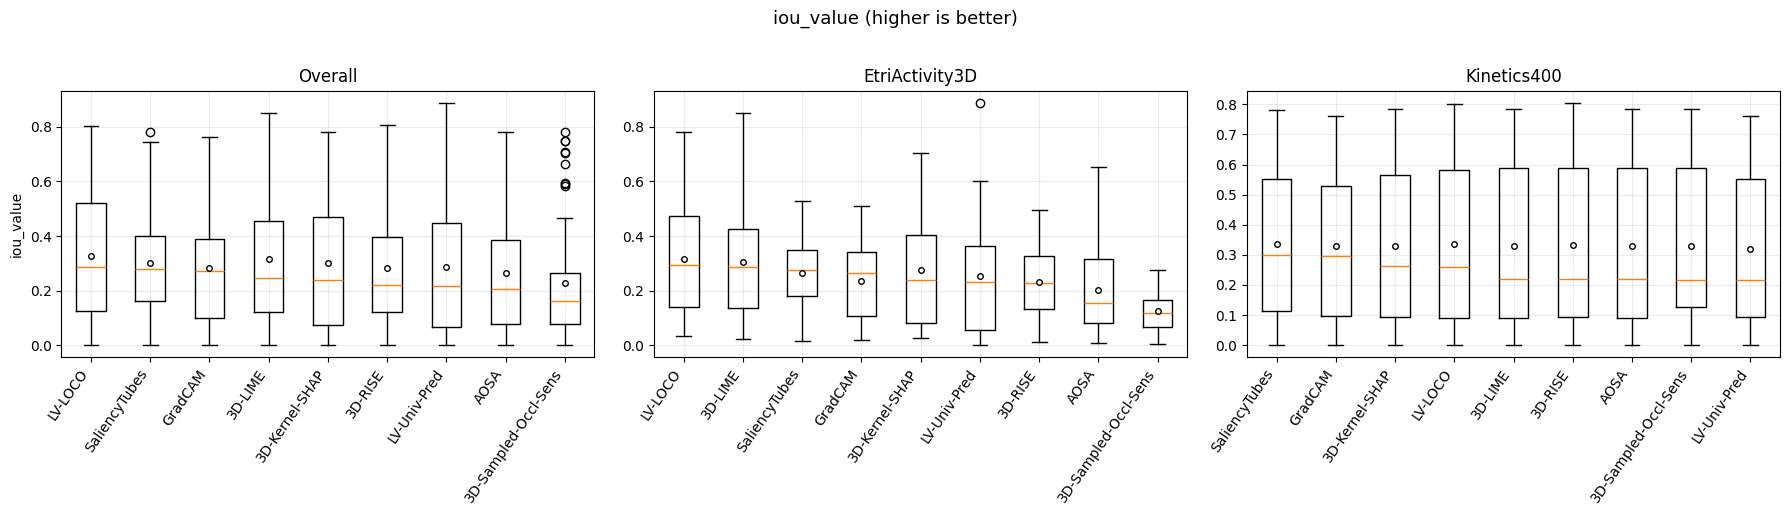

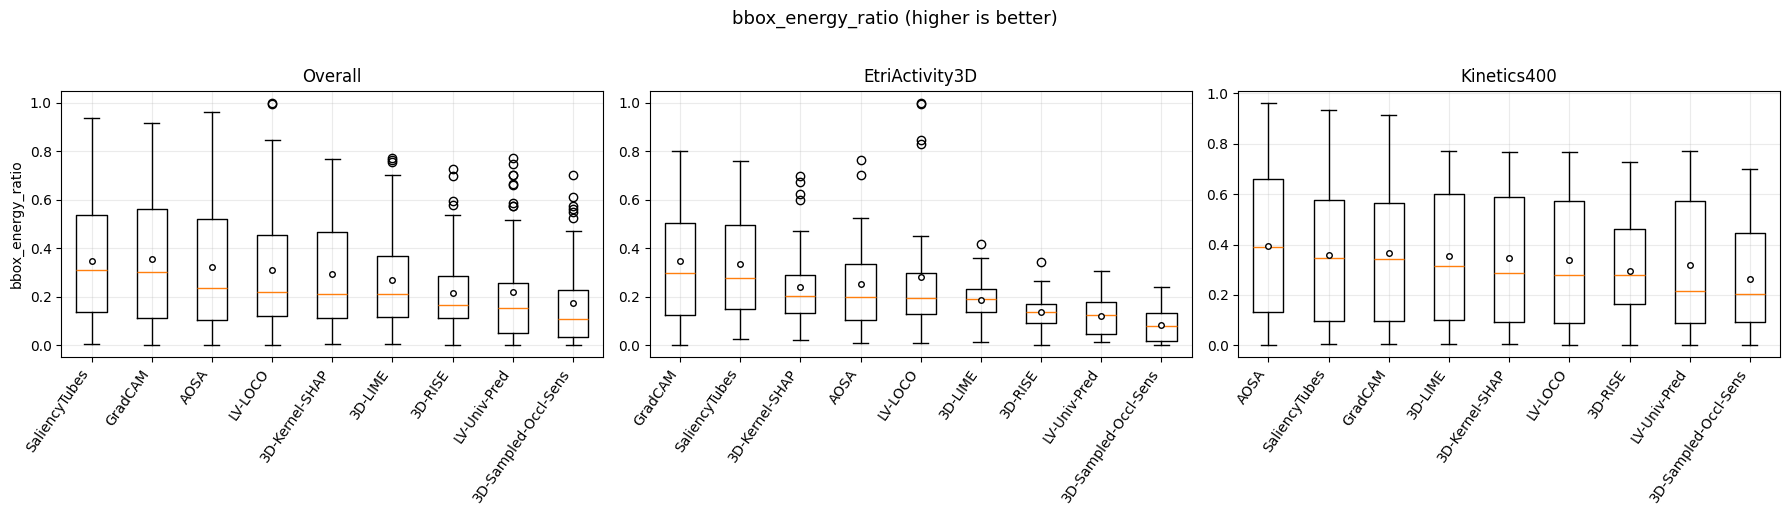

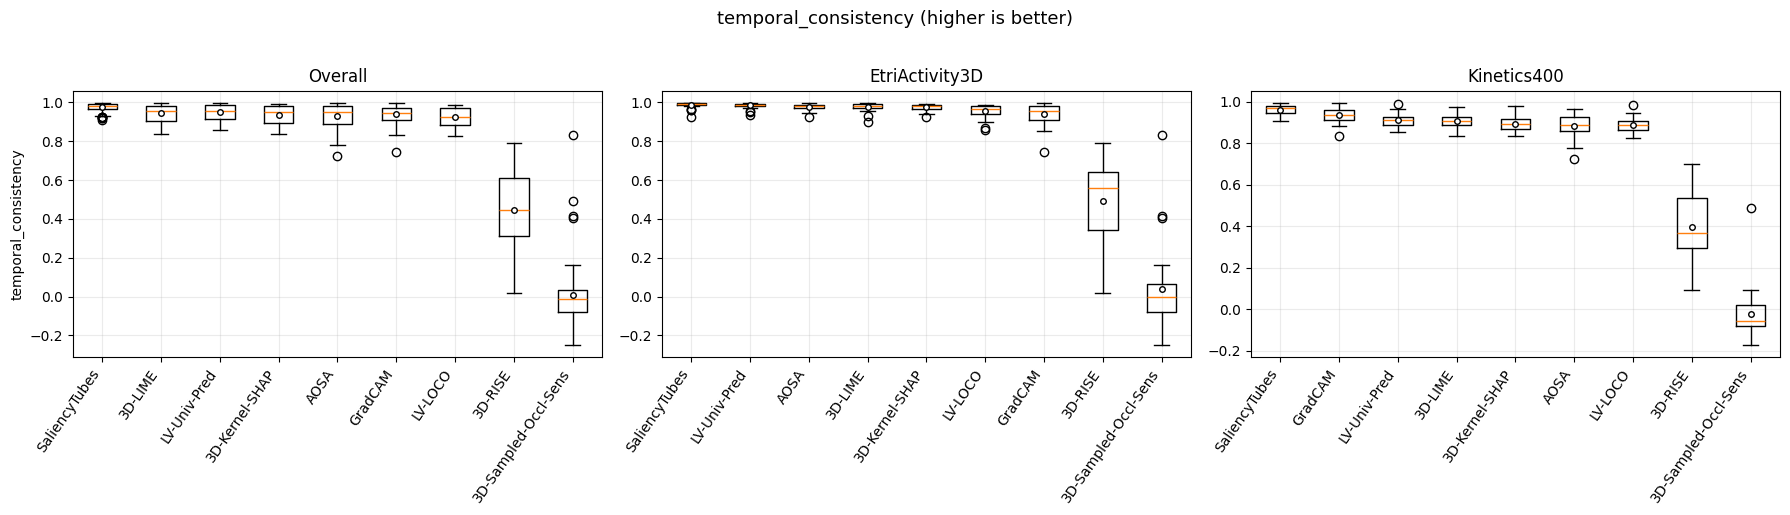

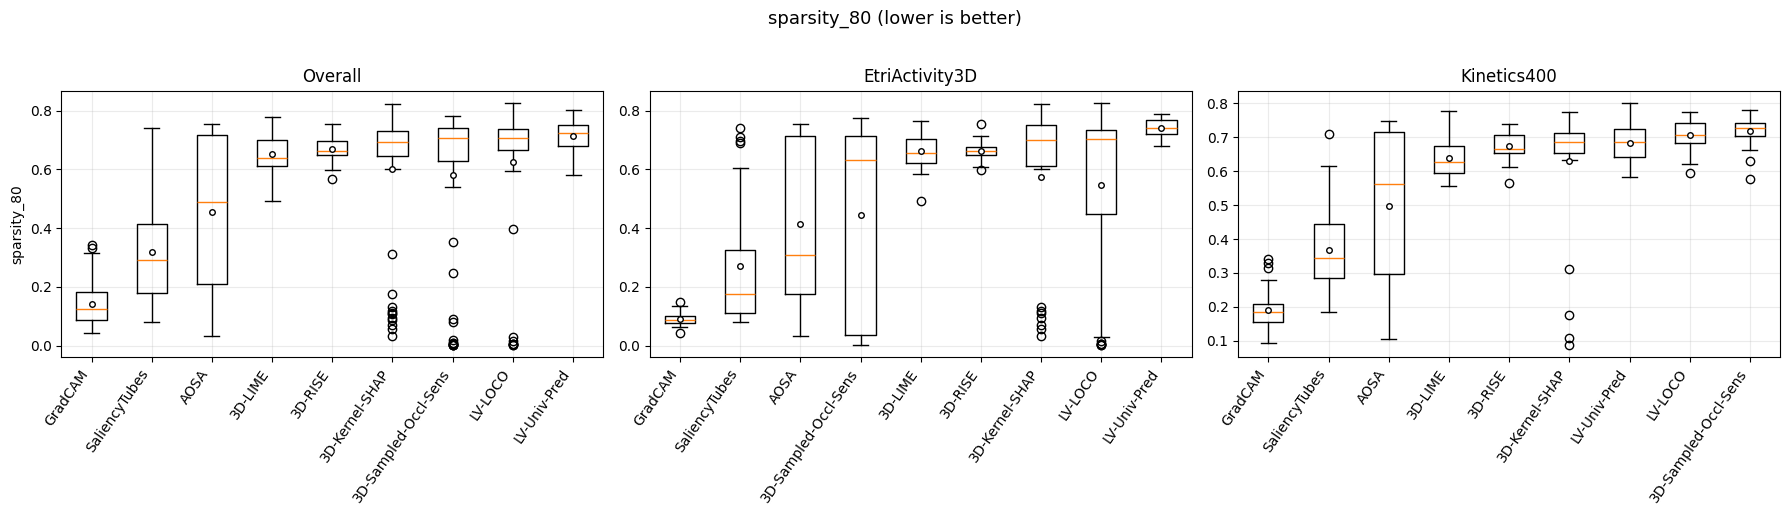

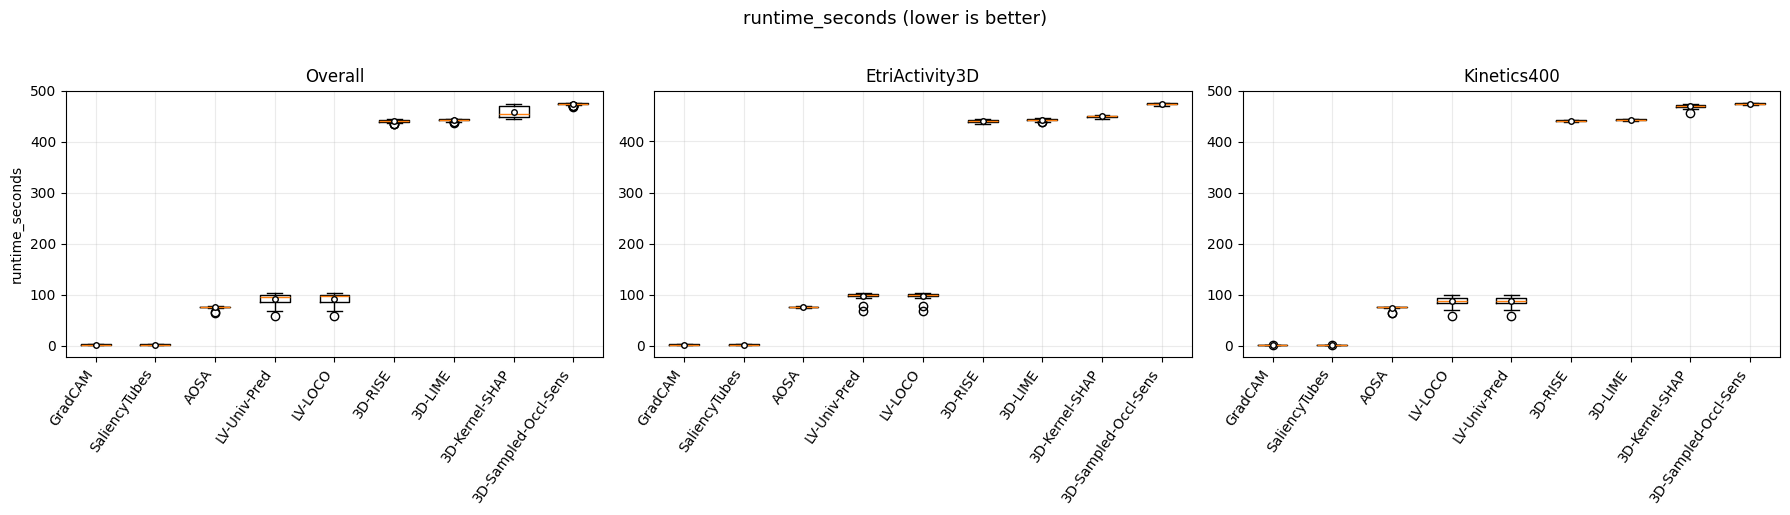

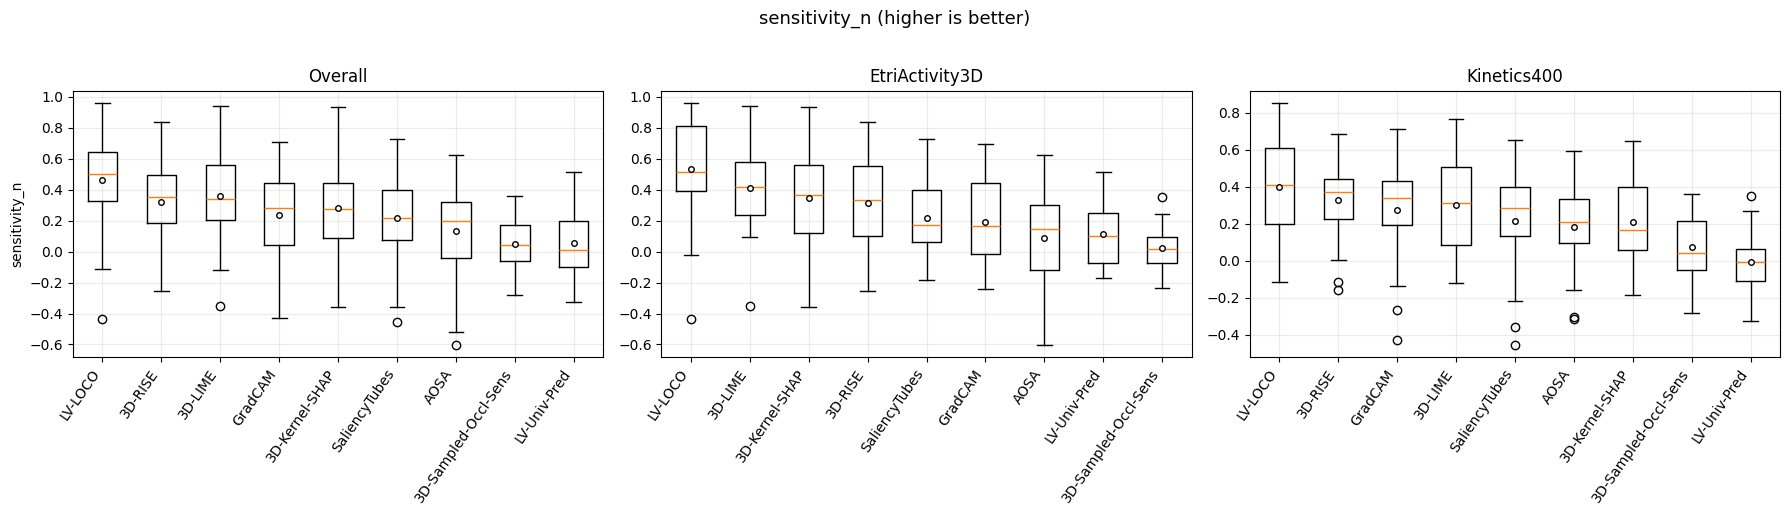

In [23]:
def plot_metric_by_scope(data, metric):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    higher = METRIC_CONFIG[metric]['higher_is_better']
    for ax, scope in zip(axes, SCOPES):
        subset = data[data['metric'].eq(metric)]
        if scope != 'Overall':
            subset = subset[subset['dataset'].eq(scope)]
        order = (subset.groupby('method')['value'].median()
                 .sort_values(ascending=not higher).index.tolist())
        values = [subset.loc[subset['method'].eq(method), 'value'].dropna().to_numpy() for method in order]
        ax.boxplot(values, tick_labels=[DISPLAY_NAMES[method] for method in order],
                   showmeans=True, meanprops={'marker': 'o', 'markerfacecolor': 'white',
                                                'markeredgecolor': 'black', 'markersize': 4})
        ax.set_title(scope)
        ax.tick_params(axis='x', rotation=55)
        for label in ax.get_xticklabels():
            label.set_ha('right')
        ax.set_ylabel(metric if ax is axes[0] else '')
    direction = 'higher is better' if higher else 'lower is better'
    fig.suptitle(f'{metric} ({direction})', y=1.02, fontsize=13)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f'{metric}_boxplots.png', dpi=160, bbox_inches='tight')
    plt.show()

for metric in METRICS:
    plot_metric_by_scope(metric_long, metric)

## 12. Summary of Statistical Findings

The following text and compact tables are generated from the computed results. They deliberately separate numerical winners from statistically supported pairwise differences and report taxonomy metrics that could not enter a repeated-video analysis.

In [24]:
removed_total = int(global_tests_df['Rows removed'].sum())
significant_global = int(global_tests_df['Significant'].sum())
significant_posthoc = int(posthoc_df['Significant'].sum()) if not posthoc_df.empty else 0
significant_dataset = int(dataset_comparison_df['Significant'].sum())
overall_best = ranking_df[ranking_df['Dataset'].eq('Overall') & ranking_df['Best']]
best_text = '; '.join(
    f"{row.Metric}: {row.Method}" for row in overall_best[['Metric', 'Method']].itertuples(index=False)
)
display(Markdown(
    f"**Computed summary (alpha = {ALPHA}):** {significant_global} of {len(global_tests_df)} "
    f"Friedman tests were significant. Their post-hoc families contained "
    f"{significant_posthoc} Holm-significant pairwise comparisons. Complete-case filtering removed "
    f"{removed_total} block rows across all metric/scope tests (a row can be counted in more than one scope). "
    f"The independent dataset analysis found {significant_dataset} Holm-significant method-level comparisons."
))
display(Markdown('**Numerical overall leaders (not significance claims):** ' + best_text))
unavailable = metric_availability_df.loc[
    ~metric_availability_df['Included in repeated-video analysis'], ['Metric', 'Reason']
]
if not unavailable.empty:
    display(Markdown('**Unavailable/excluded taxonomy metrics:** ' + '; '.join(
        f"{row.Metric} — {row.Reason}" for row in unavailable.itertuples(index=False)
    )))

final_global_tests = global_tests_df[[
    'Metric', 'Dataset', 'N', 'Friedman statistic', 'p', 'Kendall W', 'Significant'
]]
final_posthoc = posthoc_df[[
    'Metric', 'Dataset', 'Method A', 'Method B', 'p raw', 'p Holm',
    'Rank-biserial effect', 'Significant'
]]
final_ranking = ranking_df[[
    'Metric', 'Dataset', 'Rank', 'Method', 'Mean', 'Median'
]]
display(Markdown('### Global tests'))
display(final_global_tests.round(5))
display(Markdown('### Post-hoc tests'))
display(final_posthoc.round(5))
display(Markdown('### Rankings'))
display(final_ranking.round(4))

**Computed summary (alpha = 0.05):** 32 of 33 Friedman tests were significant. Their post-hoc families contained 565 Holm-significant pairwise comparisons. Complete-case filtering removed 0 block rows across all metric/scope tests (a row can be counted in more than one scope). The independent dataset analysis found 30 Holm-significant method-level comparisons.

**Numerical overall leaders (not significance claims):** avg_drop: 3D-RISE; bbox_energy_ratio: GradCAM; deletion_auc: 3D-LIME; insertion_auc: 3D-LIME; iou50: LV-LOCO; iou_value: LV-LOCO; pointing_game: 3D-LIME; runtime_seconds: GradCAM; runtime_seconds: SaliencyTubes; sensitivity_n: LV-LOCO; sparsity_80: GradCAM; temporal_consistency: SaliencyTubes

**Unavailable/excluded taxonomy metrics:** roar — Excluded: results are dataset/method/fraction-level, not per-video repeated measures.

### Global tests

,Metric,Dataset,N,Friedman statistic,p,Kendall W,Significant
0,deletion_auc,Overall,60,136.43556,0.00000,0.28424,True
1,deletion_auc,EtriActivity3D,30,83.44000,0.00000,0.34767,True
2,deletion_auc,Kinetics400,30,69.07556,0.00000,0.28781,True
3,insertion_auc,Overall,60,115.50667,0.00000,0.24064,True
4,insertion_auc,EtriActivity3D,30,108.56000,0.00000,0.45233,True
5,insertion_auc,Kinetics400,30,79.10222,0.00000,0.32959,True
6,avg_drop,Overall,60,187.90009,0.00000,0.39146,True
7,avg_drop,EtriActivity3D,30,94.29634,0.00000,0.39290,True
8,avg_drop,Kinetics400,30,133.87240,0.00000,0.55780,True
9,pointing_game,Overall,60,35.42246,0.00002,0.07380,True


### Post-hoc tests

,Metric,Dataset,Method A,Method B,p raw,p Holm,Rank-biserial effect,Significant
0,deletion_auc,Overall,3D-Kernel-SHAP,3D-LIME,0.00001,0.00025,0.65355,True
1,deletion_auc,Overall,3D-Kernel-SHAP,3D-RISE,0.59099,1.00000,0.07978,False
2,deletion_auc,Overall,3D-Kernel-SHAP,3D-Sampled-Occl-Sens,0.00000,0.00004,-0.71694,True
3,deletion_auc,Overall,3D-Kernel-SHAP,LV-LOCO,0.00001,0.00017,-0.66885,True
4,deletion_auc,Overall,3D-Kernel-SHAP,LV-Univ-Pred,0.00000,0.00000,-0.85027,True
...,...,...,...,...,...,...,...,...
1147,sensitivity_n,Kinetics400,LV-Univ-Pred,AOSA,0.00067,0.01600,-0.68172,True
1148,sensitivity_n,Kinetics400,LV-Univ-Pred,GradCAM,0.00000,0.00008,-0.88387,True
1149,sensitivity_n,Kinetics400,SaliencyTubes,AOSA,0.29884,1.00000,0.22151,False
1150,sensitivity_n,Kinetics400,SaliencyTubes,GradCAM,0.00051,0.01314,-0.69462,True


### Rankings

,Metric,Dataset,Rank,Method,Mean,Median
0,avg_drop,EtriActivity3D,1.0,3D-RISE,2.3191,0.0001
1,avg_drop,EtriActivity3D,2.0,3D-LIME,16.3615,0.6543
2,avg_drop,EtriActivity3D,3.0,SaliencyTubes,20.1009,4.8027
3,avg_drop,EtriActivity3D,4.0,AOSA,20.9533,0.4261
4,avg_drop,EtriActivity3D,5.0,3D-Kernel-SHAP,22.2154,17.1348
...,...,...,...,...,...,...
292,temporal_consistency,Overall,5.0,3D-Kernel-SHAP,0.9350,0.9512
293,temporal_consistency,Overall,6.0,AOSA,0.9312,0.9504
294,temporal_consistency,Overall,7.0,LV-LOCO,0.9227,0.9258
295,temporal_consistency,Overall,8.0,3D-RISE,0.4457,0.4449


### Reproducible outputs

Tables written to `docs/results`:

- `statistical_metric_availability.csv`
- `statistical_descriptive_summary.csv`
- `friedman_global_tests.csv`
- `wilcoxon_holm_posthoc.csv`
- `xai_method_rankings.csv`
- `dataset_mannwhitney_holm.csv`

One three-scope boxplot per automatically discovered metric is written to `docs/figures/statistical-analysis`.